<a href="https://colab.research.google.com/github/abhiniveshg0-max/DEEP-LEARNING/blob/main/Experiment%202%20part%20B.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


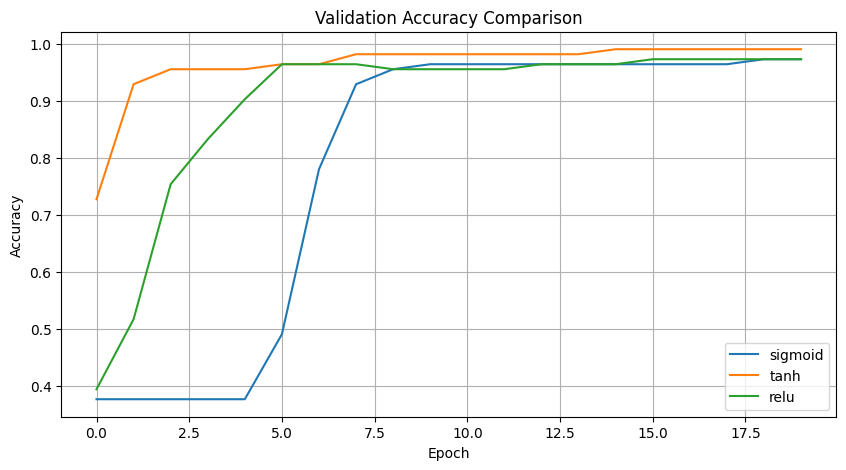

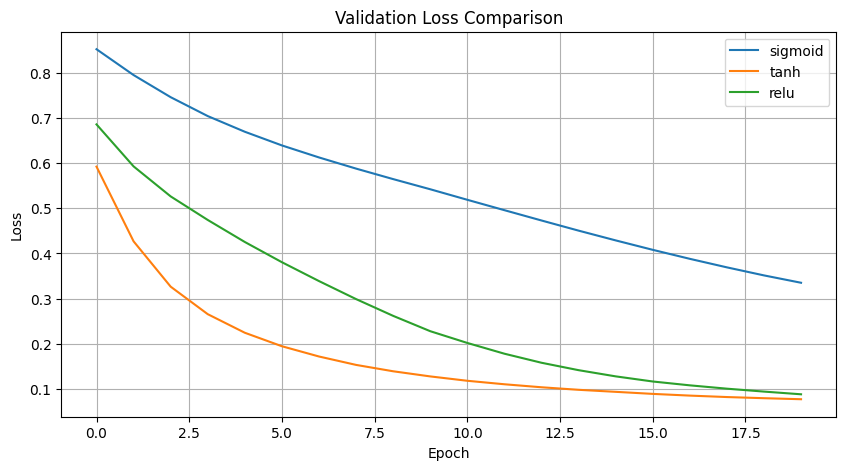


Performance Comparison

-------------------------------------
Activation : sigmoid
Training Accuracy : 0.956
Validation Accuracy : 0.9737
Training Loss : 0.3554
Validation Loss : 0.3351
Epochs : 20
-------------------------------------
Activation : tanh
Training Accuracy : 0.9802
Validation Accuracy : 0.9912
Training Loss : 0.0893
Validation Loss : 0.0769
Epochs : 20
-------------------------------------
Activation : relu
Training Accuracy : 0.9802
Validation Accuracy : 0.9737
Training Loss : 0.0964
Validation Loss : 0.0878
Epochs : 20


In [1]:
# Roll No: 24BAD001
# PART B - Performance Comparison of Activation Functions

import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt

# Load Dataset
data = load_breast_cancer()
X = data.data
y = data.target

# Split Dataset
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42)

# Feature Scaling
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

activations = ['sigmoid', 'tanh', 'relu']
history_dict = {}

for act in activations:

    model = Sequential([
        Dense(16, activation=act, input_shape=(30,)),
        Dense(8, activation=act),
        Dense(1, activation='sigmoid')
    ])

    model.compile(
        optimizer='adam',
        loss='binary_crossentropy',
        metrics=['accuracy']
    )

    history = model.fit(
        X_train,
        y_train,
        validation_data=(X_test, y_test),
        epochs=20,
        batch_size=32,
        verbose=0
    )

    history_dict[act] = history

# Plot Accuracy
plt.figure(figsize=(10,5))

for act in activations:
    plt.plot(history_dict[act].history['val_accuracy'], label=act)

plt.title("Validation Accuracy Comparison")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()
plt.grid(True)
plt.show()

# Plot Loss
plt.figure(figsize=(10,5))

for act in activations:
    plt.plot(history_dict[act].history['val_loss'], label=act)

plt.title("Validation Loss Comparison")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.grid(True)
plt.show()

# Final Results
print("\nPerformance Comparison\n")

for act in activations:
    print("-------------------------------------")
    print("Activation :", act)
    print("Training Accuracy :",
          round(history_dict[act].history['accuracy'][-1],4))
    print("Validation Accuracy :",
          round(history_dict[act].history['val_accuracy'][-1],4))
    print("Training Loss :",
          round(history_dict[act].history['loss'][-1],4))
    print("Validation Loss :",
          round(history_dict[act].history['val_loss'][-1],4))
    print("Epochs : 20")